<a href="https://colab.research.google.com/github/braulpablo-maker/app/blob/main/CursoLuan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TU_USUARIO/TU_REPO/blob/main/TU_ARCHIVO.ipynb)

#"Simulador de Colas M/M/1 - Prototipo Experimental"
##"Desarrollado por Luan & Capol"

--- ANÁLISIS PARA LAMBDA=15 y MU=25 ---
📊 Factor de Uso (Rho): 0.60 | ⏳ Tiempo en Cola: 3.60 min | 👥 Cola Promedio: 0.90 personas
--------------------------------------------------------------------------------


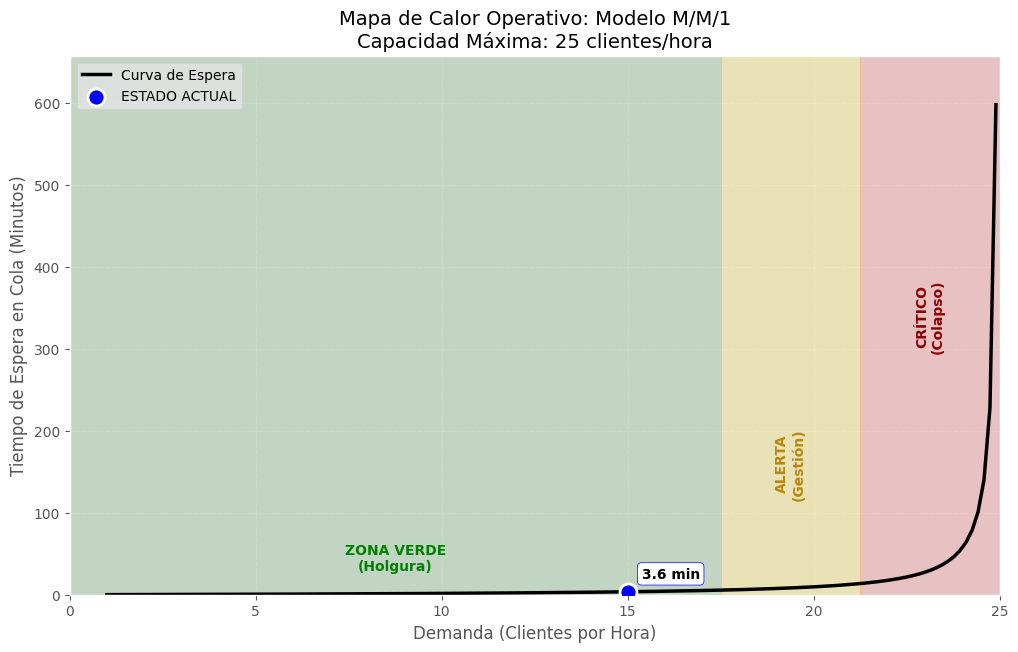

In [49]:
# --- CELDA COMBINADA: VISUALIZACIÓN + TABLERO DE CONTROL ---
# @title Tablero de Control Operativo (Zonas de Riesgo) { run: "auto" }

# 1. DEFINICIÓN DE LA FUNCIÓN GRÁFICA (Módulo 5)
def graficar_con_zonas(tasa_servicio_actual, tasa_llegada_actual):
    """Genera el gráfico con semáforo operativo."""

    # Límites de zonas (Verde < 70%, Amarilla 70-85%, Roja > 85%)
    limite_verde = tasa_servicio_actual * 0.70
    limite_amarillo = tasa_servicio_actual * 0.85

    # Generar datos de la curva
    llegadas_rango = np.linspace(1, tasa_servicio_actual - 0.1, 150)
    tiempos_espera = []

    for lam in llegadas_rango:
        rho = lam / tasa_servicio_actual
        if rho < 1:
            # Fórmula Wq en minutos
            Wq = (lam / (tasa_servicio_actual * (tasa_servicio_actual - lam))) * 60
            tiempos_espera.append(Wq)
        else:
            tiempos_espera.append(None)

    # Configuración del gráfico
    plt.figure(figsize=(12, 7))
    plt.plot(llegadas_rango, tiempos_espera, color='black', linewidth=2.5, label='Curva de Espera')

    # Pintar Zonas
    max_y = max([x for x in tiempos_espera if x is not None])

    # Zona Verde
    plt.axvspan(0, limite_verde, color='green', alpha=0.15)
    plt.text(limite_verde/2, max_y*0.05, "ZONA VERDE\n(Holgura)", ha='center', color='green', fontweight='bold')

    # Zona Amarilla
    plt.axvspan(limite_verde, limite_amarillo, color='gold', alpha=0.2)
    plt.text((limite_verde+limite_amarillo)/2, max_y*0.2, "ALERTA\n(Gestión)", ha='center', color='darkgoldenrod', fontweight='bold', rotation=90)

    # Zona Roja
    plt.axvspan(limite_amarillo, tasa_servicio_actual, color='red', alpha=0.15)
    plt.text((limite_amarillo+tasa_servicio_actual)/2, max_y*0.5, "CRÍTICO\n(Colapso)", ha='center', color='darkred', fontweight='bold', rotation=90)

    # Punto Actual
    modelo_actual = ModeloColaMM1(tasa_llegada_actual, tasa_servicio_actual)
    res = modelo_actual.calcular_kpis()
    if res:
        wa_actual = res["e) Tiempo en cola Wq (min)"]
        plt.scatter([tasa_llegada_actual], [wa_actual], color='blue', zorder=10, s=150, edgecolors='white', linewidth=2, label='ESTADO ACTUAL')
        plt.annotate(f"{wa_actual:.1f} min", (tasa_llegada_actual, wa_actual),
                     xytext=(10, 10), textcoords='offset points',
                     bbox=dict(boxstyle="round", fc="white", ec="blue"), fontweight='bold')

    plt.title(f'Mapa de Calor Operativo: Modelo M/M/1\nCapacidad Máxima: {tasa_servicio_actual} clientes/hora', fontsize=14)
    plt.xlabel('Demanda (Clientes por Hora)', fontsize=12)
    plt.ylabel('Tiempo de Espera en Cola (Minutos)', fontsize=12)
    plt.ylim(0, max_y*1.1)
    plt.xlim(0, tasa_servicio_actual)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='upper left')
    plt.show()

# 2. INTERFAZ DE USUARIO (Sliders)
Tasa_Llegadas_Lambda = 15 #@param {type:"slider", min:1, max:40, step:1}
Tasa_Servicio_Mu = 25 #@param {type:"slider", min:5, max:50, step:1}

# 3. EJECUCIÓN
print(f"--- ANÁLISIS PARA LAMBDA={Tasa_Llegadas_Lambda} y MU={Tasa_Servicio_Mu} ---")
app = ModeloColaMM1(Tasa_Llegadas_Lambda, Tasa_Servicio_Mu)
kpis = app.calcular_kpis()

if kpis:
    # Tarjetas de datos
    col1_txt = f"Factor de Uso (Rho): {kpis['c) Factor de tráfico (Rho)']:.2f}"
    col2_txt = f"Tiempo en Cola: {kpis['e) Tiempo en cola Wq (min)']:.2f} min"
    col3_txt = f"Cola Promedio: {kpis['g) Longitud cola Lq (clientes)']:.2f} personas"
    print(f"📊 {col1_txt} | ⏳ {col2_txt} | 👥 {col3_txt}")
    print("-" * 80)

    # Llamada a la gráfica definida arriba
    graficar_con_zonas(Tasa_Servicio_Mu, Tasa_Llegadas_Lambda)
else:
    print("❌ ERROR: Sistema inestable (Demanda > Capacidad).")

In [50]:
# @title
# --- CELDA 4: MOTOR DE SIMULACIÓN "GEMELO DIGITAL" (REALIDAD MINUTO A MINUTO) ---
import numpy as np
import pandas as pd

def simular_dia_operativo(tasa_llegadas, tasa_servicio, num_clientes=50):
    """
    Simula la llegada y atención de N clientes uno por uno.
    Genera variabilidad real usando distribución exponencial.
    """
    # Configuración de semilla (opcional: si quieres que siempre de lo mismo, descomenta la linea de abajo)
    # np.random.seed(42)

    # 1. Generar tiempos aleatorios (En minutos)
    # Promedio entre llegadas (1/lambda) * 60
    promedio_llegadas = (1 / tasa_llegadas) * 60
    # Promedio de servicio (1/mu) * 60
    promedio_servicio = (1 / tasa_servicio) * 60

    # Generamos los intervalos y duraciones reales para cada cliente
    t_inter_llegadas = np.random.exponential(promedio_llegadas, num_clientes)
    t_servicios = np.random.exponential(promedio_servicio, num_clientes)

    # 2. Construir la Bitácora del Día
    registros = []
    tiempo_actual = 0
    momento_llegada = 0
    momento_inicio_servicio = 0
    momento_fin_servicio = 0

    # El sistema arranca vacío
    tiempo_fin_anterior = 0

    for i in range(num_clientes):
        # El cliente llega X minutos después del anterior
        momento_llegada += t_inter_llegadas[i]

        # ¿Cuándo lo atienden?
        # Si llega y está vacío: Lo atienden ya (momento_llegada).
        # Si llega y está ocupado: Lo atienden cuando termine el anterior (tiempo_fin_anterior).
        momento_inicio_servicio = max(momento_llegada, tiempo_fin_anterior)

        # ¿Cuánto espera en cola?
        espera_cola = momento_inicio_servicio - momento_llegada

        # ¿Cuándo termina?
        momento_fin_servicio = momento_inicio_servicio + t_servicios[i]

        # Guardamos para el siguiente ciclo
        tiempo_fin_anterior = momento_fin_servicio

        # Clasificación visual para el reporte
        estado = "🟢 Fluido"
        if espera_cola > 5: estado = "🟡 Demorado"
        if espera_cola > 15: estado = "🔴 Crítico"

        registros.append({
            "Cliente #": i + 1,
            "Hora Llegada (min)": momento_llegada,
            "Duración Servicio (min)": t_servicios[i],
            "Inicio Atención": momento_inicio_servicio,
            "Fin Atención": momento_fin_servicio,
            "Tiempo en Cola (min)": espera_cola,
            "Estado": estado
        })

    return pd.DataFrame(registros)

# --- EJECUCIÓN DE LA SIMULACIÓN ---
# Usamos las variables que definiste en los sliders (si no existen, usa valores por defecto)
try:
    lam_sim = Tasa_Llegadas_Lambda
    mu_sim = Tasa_Servicio_Mu
except NameError:
    lam_sim, mu_sim = 15, 25

print(f"🎬 SIMULANDO UN DÍA DE OPERACIONES...")
print(f"Parámetros: Llegan {lam_sim}/h | Atendemos {mu_sim}/h\n")

df_simulacion = simular_dia_operativo(lam_sim, mu_sim, num_clientes=20)

# Formateo visual de la tabla
display(df_simulacion.style.format({
    "Hora Llegada (min)": "{:.2f}",
    "Duración Servicio (min)": "{:.2f}",
    "Inicio Atención": "{:.2f}",
    "Fin Atención": "{:.2f}",
    "Tiempo en Cola (min)": "{:.2f}"
}).background_gradient(subset=["Tiempo en Cola (min)"], cmap="Reds"))

# Comparativa Real vs Teórica
espera_real_promedio = df_simulacion["Tiempo en Cola (min)"].mean()
print(f"\n💡 CONCLUSIÓN DE LA SIMULACIÓN:")
print(f"El promedio matemático dice que deberían esperar: 3.60 min")
print(f"En ESTA simulación real, el promedio fue: {espera_real_promedio:.2f} min")
if espera_real_promedio > 3.6:
    print("👉 Hoy tuvimos 'mala suerte' (variabilidad negativa).")
else:
    print("👉 Hoy el flujo fue mejor de lo esperado.")

🎬 SIMULANDO UN DÍA DE OPERACIONES...
Parámetros: Llegan 15/h | Atendemos 25/h



,Cliente #,Hora Llegada (min),Duración Servicio (min),Inicio Atención,Fin Atención,Tiempo en Cola (min),Estado
0,1,3.97,0.25,3.97,4.21,0.00,🟢 Fluido
1,2,4.12,2.84,4.21,7.06,0.09,🟢 Fluido
2,3,5.30,1.96,7.06,9.02,1.76,🟢 Fluido
3,4,26.99,2.81,26.99,29.80,0.00,🟢 Fluido
4,5,32.71,0.60,32.71,33.31,0.00,🟢 Fluido
5,6,40.44,3.82,40.44,44.26,0.00,🟢 Fluido
6,7,45.98,0.36,45.98,46.35,0.00,🟢 Fluido
7,8,53.53,3.51,53.53,57.04,0.00,🟢 Fluido
8,9,54.65,2.49,57.04,59.53,2.39,🟢 Fluido
9,10,59.62,0.29,59.62,59.91,0.00,🟢 Fluido



💡 CONCLUSIÓN DE LA SIMULACIÓN:
El promedio matemático dice que deberían esperar: 3.60 min
En ESTA simulación real, el promedio fue: 0.65 min
👉 Hoy el flujo fue mejor de lo esperado.


In [22]:
# @title
# --- CELDA 1: IMPORTACIÓN DE LIBRERÍAS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para los gráficos (lo usaremos más adelante)
plt.style.use('ggplot')
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Librerías importadas y entorno configurado correctamente.")

✅ Librerías importadas y entorno configurado correctamente.


In [23]:
# @title
# --- CELDA 2: CLASE DE LÓGICA DE NEGOCIO (MODELO M/M/1) ---

class ModeloColaMM1:
    def __init__(self, tasa_llegadas, tasa_servicio):
        """
        Inicializa el modelo M/M/1.
        :param tasa_llegadas (lambda): Clientes por hora
        :param tasa_servicio (mu): Clientes por hora
        """
        self.lam = tasa_llegadas
        self.mu = tasa_servicio

        # Validación de estabilidad
        if self.lam >= self.mu:
            print(f"⚠️ ALERTA CRÍTICA: El sistema es inestable (Lambda {self.lam} >= Mu {self.mu}). La cola crecerá infinitamente.")
            self.estable = False
        else:
            self.estable = True

    def calcular_kpis(self):
        """Calcula todos los indicadores clave del Práctico."""
        if not self.estable:
            return None

        # Fórmulas del Modelo M/M/1
        rho = self.lam / self.mu  # Factor de tráfico
        p0 = 1 - rho              # Probabilidad de sistema vacío (tiempo ocioso)

        # Tiempos (en horas originalmente)
        L_s = self.lam / (self.mu - self.lam)  # Longitud media del sistema (clientes)
        L_q = L_s - rho                        # Longitud media de la cola (clientes)

        W_s_horas = 1 / (self.mu - self.lam)   # Tiempo medio en sistema (horas)
        W_q_horas = W_s_horas - (1 / self.mu)  # Tiempo medio en cola (horas)

        # Conversión a Minutos para facilitar lectura
        W_s_min = W_s_horas * 60
        W_q_min = W_q_horas * 60
        t_entre_arribos = (1 / self.lam) * 60
        t_servicio = (1 / self.mu) * 60

        # Retornamos un diccionario ordenado con los resultados
        return {
            "a) Tiempo entre arribos (min)": t_entre_arribos,
            "b) Tiempo de servicio (min)": t_servicio,
            "c) Factor de tráfico (Rho)": rho,
            "d) Tiempo en sistema Ws (min)": W_s_min,
            "e) Tiempo en cola Wq (min)": W_q_min,
            "f) Longitud sistema Ls (clientes)": L_s,
            "g) Longitud cola Lq (clientes)": L_q,
            "h) % Tiempo Ocioso": p0 * 100,
            "i) Probabilidad de no esperar": p0
        }

# --- VALIDACIÓN CON TU EJERCICIO ---
# Instanciamos la clase con tus datos: 15 llegadas/h, 25 servicio/h
modelo_prueba = ModeloColaMM1(tasa_llegadas=15, tasa_servicio=25)
resultados = modelo_prueba.calcular_kpis()

print("--- RESULTADOS DE LA VALIDACIÓN (COTEJAR CON EL PRÁCTICO) ---")
for k, v in resultados.items():
    print(f"{k}: {v:.2f}")

--- RESULTADOS DE LA VALIDACIÓN (COTEJAR CON EL PRÁCTICO) ---
a) Tiempo entre arribos (min): 4.00
b) Tiempo de servicio (min): 2.40
c) Factor de tráfico (Rho): 0.60
d) Tiempo en sistema Ws (min): 6.00
e) Tiempo en cola Wq (min): 3.60
f) Longitud sistema Ls (clientes): 1.50
g) Longitud cola Lq (clientes): 0.90
h) % Tiempo Ocioso: 40.00
i) Probabilidad de no esperar: 0.40


In [44]:
# @title
# --- CELDA 3: MÓDULO DE VISUALIZACIÓN ESTRATÉGICA ---

def graficar_sensibilidad(tasa_servicio_actual, tasa_llegada_actual):
    """
    Genera un gráfico de sensibilidad mostrando cómo aumenta la espera
    a medida que nos acercamos a la capacidad máxima del servidor.
    """
    # 1. Creamos un rango de posibles llegadas (desde 1 hasta casi la capacidad máxima)
    # Generamos valores de llegada desde 1 hasta (tasa_servicio - 0.5) para no dividir por cero
    llegadas_rango = np.linspace(1, tasa_servicio_actual - 0.1, 100)

    tiempos_espera = []

    # 2. Calculamos Wq (Tiempo en cola) para cada escenario
    for lam in llegadas_rango:
        modelo = ModeloColaMM1(lam, tasa_servicio_actual)
        res = modelo.calcular_kpis()
        if res:
            tiempos_espera.append(res["e) Tiempo en cola Wq (min)"])
        else:
            tiempos_espera.append(None)

    # 3. Graficamos
    plt.figure(figsize=(10, 6))

    # Curva de comportamiento
    plt.plot(llegadas_rango, tiempos_espera, label='Tiempo de Espera en Cola', color='darkblue', linewidth=2)

    # Punto actual del ejercicio
    modelo_actual = ModeloColaMM1(tasa_llegada_actual, tasa_servicio_actual)
    res_actual = modelo_actual.calcular_kpis()
    wa_actual = res_actual["e) Tiempo en cola Wq (min)"]

    plt.scatter([tasa_llegada_actual], [wa_actual], color='red', zorder=5, s=100, label=f'Situación Actual ({tasa_llegada_actual} cl/h)')

    # Líneas de referencia
    plt.axvline(x=tasa_servicio_actual, color='red', linestyle='--', label='Capacidad Máxima (Colapso)')
    plt.title(f'Análisis de Sensibilidad: Impacto de la Demanda en la Espera\n(Capacidad de Servicio fija: {tasa_servicio_actual} cl/h)', fontsize=14)
    plt.xlabel('Tasa de Llegada de Clientes ($\lambda$)', fontsize=12)
    plt.ylabel('Tiempo Promedio en Cola (minutos)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.show()

print("✅ Módulo de gráficos cargado.")

✅ Módulo de gráficos cargado.


<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-194827937.py:40: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Tasa de Llegada de Clientes ($\lambda$)', fontsize=12)
